In [40]:
import os, copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

In [41]:
IMG_SIZE   = 64
BATCH_SIZE = 32
LATENT_DIM = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [42]:
# load data
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")
dataset_path = os.path.join(path, "Celebrity Faces Dataset")

records = []
for celebrity in sorted(os.listdir(dataset_path)):
    celeb_dir = os.path.join(dataset_path, celebrity)
    if not os.path.isdir(celeb_dir):
        continue
    for img_file in os.listdir(celeb_dir):
        if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({
                "identity": celebrity,
                "filepath": os.path.join(celeb_dir, img_file)
            })

df = pd.DataFrame(records)
identity_names = sorted(df["identity"].unique())
name_to_label  = {name: i for i, name in enumerate(identity_names)}
df["label"]    = df["identity"].map(name_to_label)

print(f"Total images: {len(df)}")
print(f"Images per celebrity:\n{df['identity'].value_counts()}")

Total images: 1800
Images per celebrity:
identity
Scarlett Johansson    200
Angelina Jolie        100
Brad Pitt             100
Denzel Washington     100
Hugh Jackman          100
Jennifer Lawrence     100
Johnny Depp           100
Kate Winslet          100
Leonardo DiCaprio     100
Megan Fox             100
Natalie Portman       100
Nicole Kidman         100
Robert Downey Jr      100
Sandra Bullock        100
Tom Cruise            100
Tom Hanks             100
Will Smith            100
Name: count, dtype: int64


In [43]:
# forget/retain set
forget_celebrity = identity_names[0]
print(f"Forget target: {forget_celebrity}")

forget_df = df[df["identity"] == forget_celebrity].reset_index(drop=True)
retain_df = df[df["identity"] != forget_celebrity].reset_index(drop=True)

print(f"Forget set: {len(forget_df)} images")
print(f"Retain set: {len(retain_df)} images")

Forget target: Angelina Jolie
Forget set: 100 images
Retain set: 1700 images


In [44]:
# dataset + dataloaders
class CelebDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label, autoencoder doesn't use it

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

forget_dataset = CelebDataset(forget_df, transform)
retain_dataset  = CelebDataset(retain_df, transform)
full_dataset    = ConcatDataset([forget_dataset, retain_dataset])

forget_loader = DataLoader(forget_dataset, batch_size=BATCH_SIZE, shuffle=True)
retain_loader  = DataLoader(retain_dataset,  batch_size=BATCH_SIZE, shuffle=True)
full_loader    = DataLoader(full_dataset,    batch_size=BATCH_SIZE, shuffle=True)

print(f"Forget batches: {len(forget_loader)} | Retain batches: {len(retain_loader)}")

Forget batches: 4 | Retain batches: 54


In [45]:
# ae model
import torch
import torch.nn as nn

class ResBlock(nn.Module):
    """Residual block — helps gradients flow and sharpens reconstructions"""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(x + self.block(x))  # skip connection


class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            # 64 → 32
            nn.Conv2d(3, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            ResBlock(64),

            # 32 → 16
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            ResBlock(128),

            # 16 → 8
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            ResBlock(256),

            # 8 → 4
            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            ResBlock(512),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        return self.fc(self.flatten(self.net(x)))


class Decoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.net = nn.Sequential(
            ResBlock(512),
            # 4 → 8
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            ResBlock(256),

            # 8 → 16
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            ResBlock(128),

            # 16 → 32
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            ResBlock(64),

            # 32 → 64
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 4, 4))


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))

LATENT_DIM = 256
ae_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
print(f"Autoencoder params: {sum(p.numel() for p in ae_model.parameters()):,}")

Autoencoder params: 22,263,427


In [46]:
# perceptual loss
from torchvision.models import vgg16, VGG16_Weights

class PerceptualLoss(nn.Module):
    """Uses VGG feature maps instead of raw pixels — huge quality improvement"""
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.DEFAULT).features
        # Use first 3 blocks of VGG for perceptual features
        self.slice1 = nn.Sequential(*list(vgg)[:4]).eval()   # edges
        self.slice2 = nn.Sequential(*list(vgg)[4:9]).eval()  # textures
        self.slice3 = nn.Sequential(*list(vgg)[9:16]).eval() # structure
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, pred, target):
        # Normalize to VGG's expected input range
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(pred.device)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(pred.device)
        pred   = (pred   - mean) / std
        target = (target - mean) / std

        loss = 0
        x, y = pred, target
        for layer in [self.slice1, self.slice2, self.slice3]:
            x = layer(x)
            y = layer(y)
            loss += nn.functional.mse_loss(x, y)
        return loss

perceptual_loss = PerceptualLoss().to(device)

In [47]:
# training w/ combined loss
# MSE keeps pixel accuracy, perceptual loss keeps sharpness/structure
# SSIM adds structural similarity on top

from pytorch_msssim import ssim  # pip install pytorch-msssim if necessary

def combined_loss(pred, target, w_mse=1.0, w_perc=0.1, w_ssim=0.5):
    mse  = nn.functional.mse_loss(pred, target)
    perc = perceptual_loss(pred, target)
    sim  = 1 - ssim(pred, target, data_range=1.0, size_average=True)
    return w_mse * mse + w_perc * perc + w_ssim * sim

optimizer = torch.optim.AdamW(ae_model.parameters(), lr=5e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

def train(model, loader, epochs=30):
    model.train()
    for epoch in range(epochs):
        total = 0
        for images, _ in loader:
            images = images.to(device)
            pred   = model(images)
            loss   = combined_loss(pred, images)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # stability
            optimizer.step()
            total += loss.item()
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {total/len(loader):.5f} | LR: {lr:.6f}")

train(ae_model, full_loader, epochs=100)

os.makedirs("models", exist_ok=True)
torch.save(ae_model.state_dict(), "models/AE_orig.pt")
print("Saved.")

Epoch  1/100 | Loss: 5.09229 | LR: 0.000050
Epoch  2/100 | Loss: 4.59532 | LR: 0.000049
Epoch  3/100 | Loss: 4.50050 | LR: 0.000049
Epoch  4/100 | Loss: 4.41993 | LR: 0.000048
Epoch  5/100 | Loss: 4.35739 | LR: 0.000047
Epoch  6/100 | Loss: 4.27019 | LR: 0.000045
Epoch  7/100 | Loss: 4.19309 | LR: 0.000044
Epoch  8/100 | Loss: 4.13866 | LR: 0.000042
Epoch  9/100 | Loss: 4.06918 | LR: 0.000040
Epoch 10/100 | Loss: 3.99858 | LR: 0.000038
Epoch 11/100 | Loss: 3.92516 | LR: 0.000035
Epoch 12/100 | Loss: 3.86202 | LR: 0.000033
Epoch 13/100 | Loss: 3.78775 | LR: 0.000031
Epoch 14/100 | Loss: 3.71635 | LR: 0.000028
Epoch 15/100 | Loss: 3.64561 | LR: 0.000026
Epoch 16/100 | Loss: 3.55612 | LR: 0.000023
Epoch 17/100 | Loss: 3.50755 | LR: 0.000020
Epoch 18/100 | Loss: 3.42529 | LR: 0.000018
Epoch 19/100 | Loss: 3.39429 | LR: 0.000016
Epoch 20/100 | Loss: 3.33934 | LR: 0.000013
Epoch 21/100 | Loss: 3.28460 | LR: 0.000011
Epoch 22/100 | Loss: 3.25269 | LR: 0.000009
Epoch 23/100 | Loss: 3.20087 | L

In [48]:
def compute_mse(model, loader):
    model.eval()
    total, count = 0, 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            recon  = model(images)
            total += nn.functional.mse_loss(recon, images).item() * images.size(0)
            count += images.size(0)
    return total / count

def show_reconstructions(model, loader, title="", n=8):
    model.eval()
    images, _ = next(iter(loader))
    images = images[:n].to(device)
    with torch.no_grad():
        recons = model(images)
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0,i].imshow(images[i].cpu().permute(1,2,0).clamp(0,1))
        axes[0,i].axis("off")
        axes[1,i].imshow(recons[i].cpu().permute(1,2,0).clamp(0,1))
        axes[1,i].axis("off")
    axes[0,0].set_title("Original", fontsize=9)
    axes[1,0].set_title("Reconstructed", fontsize=9)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

BEFORE — Forget MSE: 0.01787 | Retain MSE: 0.02863


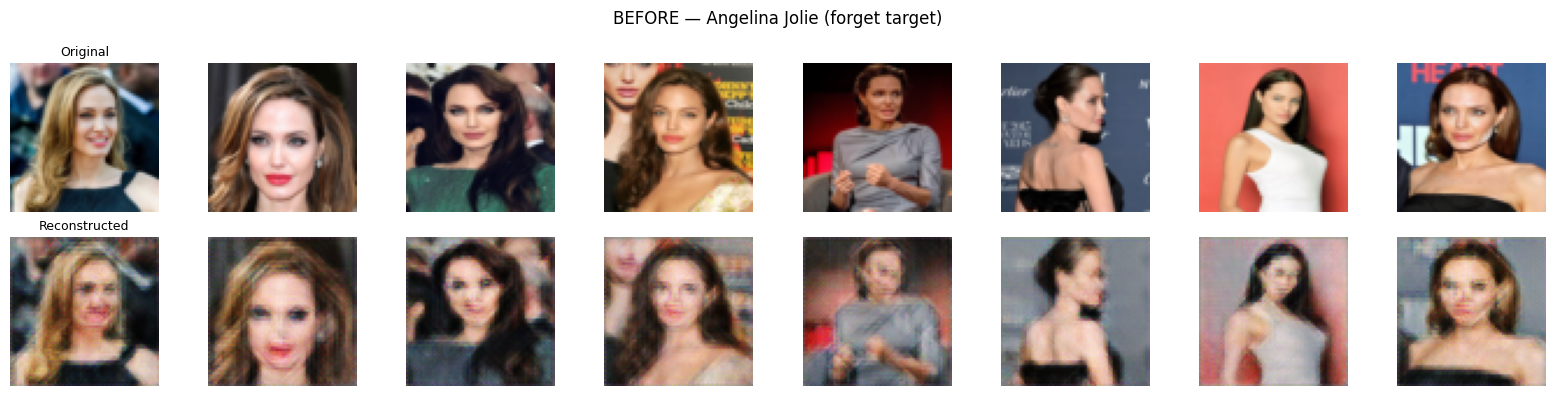

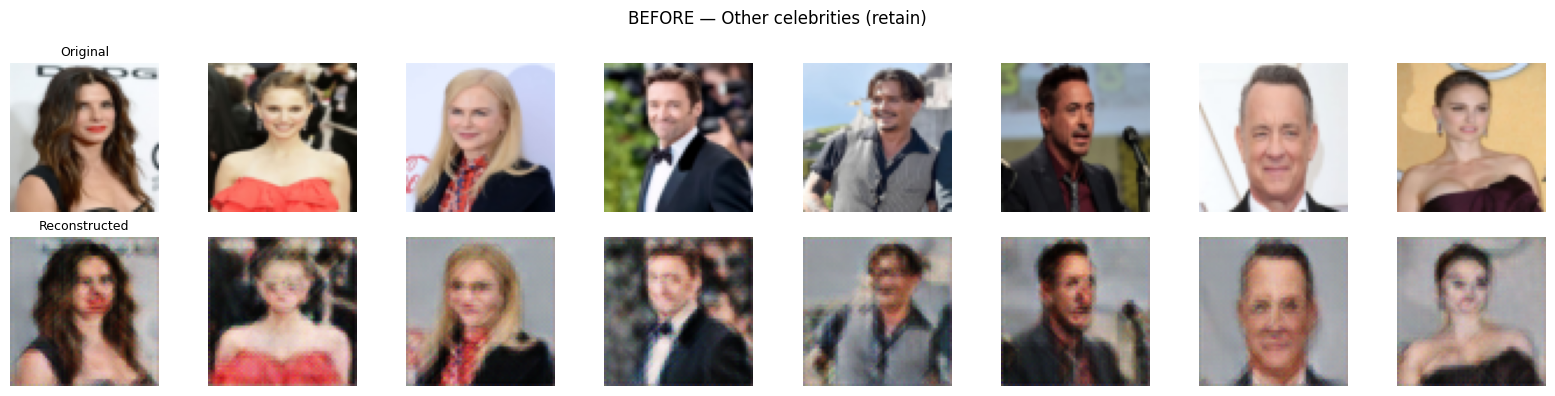

In [49]:
# baseline metrics
forget_mse_before = compute_mse(ae_model, forget_loader)
retain_mse_before = compute_mse(ae_model, retain_loader)
print(f"BEFORE — Forget MSE: {forget_mse_before:.5f} | Retain MSE: {retain_mse_before:.5f}")

show_reconstructions(ae_model, forget_loader, title=f"BEFORE — {forget_celebrity} (forget target)")
show_reconstructions(ae_model, retain_loader, title="BEFORE — Other celebrities (retain)")